# Computer Vision Assignment 3 - PCB Defect Detection

**Name:** Aiman  
**Roll Number:** 22F-3480  
**Section:** BS(EE)-8A  
**Course:** CS4059 - Introduction to Computer Vision

This notebook contains a complete end-to-end solution for **Question 1 (PCB Defect Detection)**.

In [1]:
!pip -q install kagglehub grad-cam seaborn scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 109.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os, random, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [3]:
import kagglehub

ROOT = Path.cwd()
DATA_ROOT = ROOT / 'Q1_PCB_Defect_Detection' / 'data'
RAW_DIR = DATA_ROOT / 'raw'
SPLIT_DIR = DATA_ROOT / 'split'
for p in [RAW_DIR, SPLIT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Downloading dataset (first time may take long)...')
kaggle_path = Path(kagglehub.dataset_download('akhatova/pcb-defects'))
print('Downloaded to:', kaggle_path)

if not any(RAW_DIR.iterdir()):
    shutil.copytree(kaggle_path, RAW_DIR, dirs_exist_ok=True)
print('Local raw dataset path:', RAW_DIR)

100%|██████████| 1.88G/1.88G [01:56<00:00, 17.2MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/akhatova/pcb-defects/versions/1
Local raw dataset path: /content/Q1_PCB_Defect_Detection/data/raw


Detected classes: ['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']
Total images: 693
label
Short              116
Open_circuit       116
Spurious_copper    116
Missing_hole       115
Mouse_bite         115
Spur               115
Name: count, dtype: int64


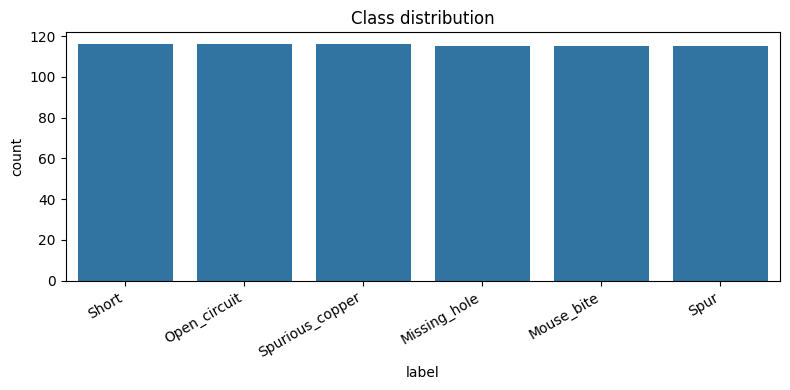

In [4]:
def find_class_dirs(root: Path):
    candidates = []
    for d in Path(root).rglob('*'):
        if d.is_dir():
            imgs = list(d.glob('*.jpg')) + list(d.glob('*.jpeg')) + list(d.glob('*.png')) + list(d.glob('*.bmp'))
            if len(imgs) >= 20:
                candidates.append((d, len(imgs)))
    parents = {}
    for d, n in candidates:
        parents.setdefault(d.parent, []).append((d, n))
    best_parent, best_count = None, 0
    for p, items in parents.items():
        total = sum(n for _, n in items)
        if len(items) >= 2 and total > best_count:
            best_parent, best_count = p, total
    if best_parent is None:
        raise RuntimeError('Could not infer class folders. Inspect RAW_DIR manually.')
    return sorted([d for d, _ in parents[best_parent]])

class_dirs = find_class_dirs(RAW_DIR)
print('Detected classes:', [d.name for d in class_dirs])

rows = []
for d in class_dirs:
    for f in d.glob('**/*'):
        if f.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}:
            rows.append({'path': str(f), 'label': d.name})

df = pd.DataFrame(rows)
print('Total images:', len(df))
print(df['label'].value_counts())

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.xticks(rotation=30, ha='right')
plt.title('Class distribution')
plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

def prepare_split(df, out_dir: Path, train=0.7, val=0.15, test=0.15):
    assert abs((train + val + test) - 1.0) < 1e-6
    out_dir = Path(out_dir)
    if all((out_dir / s).exists() for s in ['train', 'val', 'test']):
        print('Using existing split at', out_dir)
        return

    train_df, temp_df = train_test_split(df, test_size=(1 - train), stratify=df['label'], random_state=SEED)
    rel_val = val / (val + test)
    val_df, test_df = train_test_split(temp_df, test_size=(1 - rel_val), stratify=temp_df['label'], random_state=SEED)

    splits = {'train': train_df, 'val': val_df, 'test': test_df}
    for s, sdf in splits.items():
        for _, row in sdf.iterrows():
            src = Path(row['path'])
            dst = out_dir / s / row['label'] / src.name
            dst.parent.mkdir(parents=True, exist_ok=True)
            if not dst.exists():
                shutil.copy2(src, dst)
    print({k: len(v) for k, v in splits.items()})

prepare_split(df, SPLIT_DIR)

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x + 0.02 * torch.randn_like(x)),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_test_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = datasets.ImageFolder(SPLIT_DIR / 'train', transform=train_tfms)
val_ds = datasets.ImageFolder(SPLIT_DIR / 'val', transform=val_test_tfms)
test_ds = datasets.ImageFolder(SPLIT_DIR / 'test', transform=val_test_tfms)

class_to_idx = train_ds.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
print('Classes:', class_to_idx)

labels = [y for _, y in train_ds.samples]
class_counts = np.bincount(labels)
weights = 1.0 / class_counts
sample_weights = np.array([weights[y] for y in labels])
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print('Train/Val/Test sizes:', len(train_ds), len(val_ds), len(test_ds))

{'train': 485, 'val': 104, 'test': 104}
Classes: {'Missing_hole': 0, 'Mouse_bite': 1, 'Open_circuit': 2, 'Short': 3, 'Spur': 4, 'Spurious_copper': 5}
Train/Val/Test sizes: 485 104 104


In [6]:
class PCB_CNN(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(), nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.4), nn.Linear(512, n_classes))

    def forward(self, x):
        return self.classifier(self.features(x))

class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.skip = nn.Identity()
        if stride != 1 or in_ch != out_ch:
            self.skip = nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, stride, bias=False), nn.BatchNorm2d(out_ch))

    def forward(self, x):
        identity = self.skip(x)
        out = torch.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = torch.relu(out + identity)
        return out

class PCB_ResNet(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(3, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2))
        self.layer1 = ResidualBlock(64, 64, 1)
        self.layer2 = ResidualBlock(64, 128, 2)
        self.layer3 = ResidualBlock(128, 256, 2)
        self.layer4 = ResidualBlock(256, 512, 2)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, n_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x).flatten(1)
        return self.fc(x)

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cnn = PCB_CNN(len(class_to_idx)).to(device)
resnet = PCB_ResNet(len(class_to_idx)).to(device)
print('CNN params:', count_params(cnn))
print('ResNet params:', count_params(resnet))

CNN params: 1573638
ResNet params: 4901190


[cnn] Epoch 01 | train_loss 1.9337 | val_loss 1.8244 | train_acc 0.1711 | val_acc 0.2115
[cnn] Epoch 02 | train_loss 1.8465 | val_loss 1.8817 | train_acc 0.1629 | val_acc 0.1154
[cnn] Epoch 03 | train_loss 1.8135 | val_loss 1.8757 | train_acc 0.1897 | val_acc 0.1538
[cnn] Epoch 04 | train_loss 1.8318 | val_loss 1.8594 | train_acc 0.1485 | val_acc 0.1442
[cnn] Epoch 05 | train_loss 1.8467 | val_loss 1.8651 | train_acc 0.1546 | val_acc 0.1731
[cnn] Epoch 06 | train_loss 1.8274 | val_loss 1.8267 | train_acc 0.1814 | val_acc 0.1442
[cnn] Epoch 07 | train_loss 1.8108 | val_loss 1.8199 | train_acc 0.1711 | val_acc 0.1442
[cnn] Epoch 08 | train_loss 1.7841 | val_loss 1.8662 | train_acc 0.1959 | val_acc 0.1250
[cnn] Epoch 09 | train_loss 1.8254 | val_loss 1.8466 | train_acc 0.1649 | val_acc 0.1538
[cnn] Epoch 10 | train_loss 1.8023 | val_loss 1.8258 | train_acc 0.1753 | val_acc 0.1346
[cnn] Epoch 11 | train_loss 1.8007 | val_loss 1.8327 | train_acc 0.1876 | val_acc 0.1154
[cnn] Epoch 12 | trai

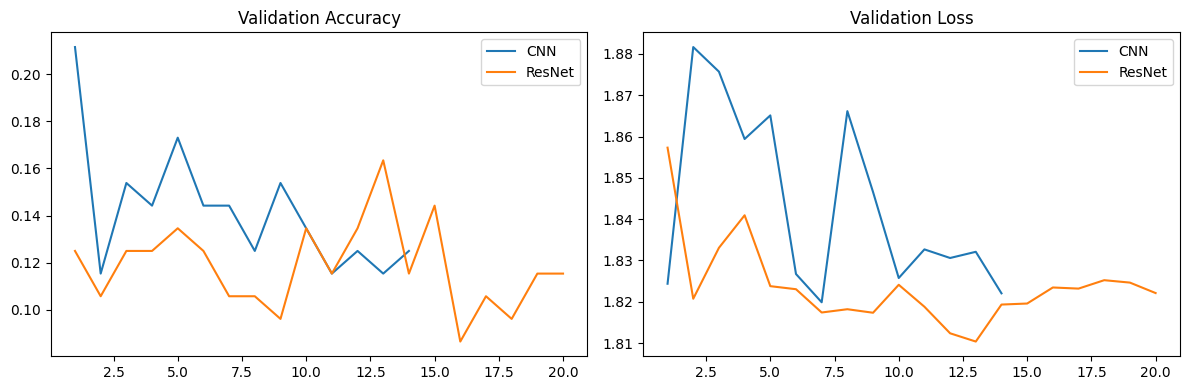

In [7]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, total_correct, total = 0.0, 0, 0
    all_probs, all_targets = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.set_grad_enabled(is_train):
            logits = model(x)
            loss = criterion(logits, y)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)
        total_loss += loss.item() * x.size(0)
        total_correct += (preds == y).sum().item()
        total += x.size(0)
        all_probs.append(probs.detach().cpu())
        all_targets.append(y.detach().cpu())

    return {
        'loss': total_loss / total,
        'acc': total_correct / total,
        'probs': torch.cat(all_probs).numpy(),
        'targets': torch.cat(all_targets).numpy()
    }

def train_model(model, name, epochs=5, lr=1e-3, patience=7):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    history = []
    best_val = np.inf
    bad = 0
    ckpt = Path(f'best_{name}.pt')

    for ep in range(1, epochs + 1):
        tr = run_epoch(model, train_loader, criterion, optimizer)
        va = run_epoch(model, val_loader, criterion, None)
        scheduler.step(va['loss'])
        history.append({'epoch': ep, 'train_loss': tr['loss'], 'val_loss': va['loss'], 'train_acc': tr['acc'], 'val_acc': va['acc']})
        print(f"[{name}] Epoch {ep:02d} | train_loss {tr['loss']:.4f} | val_loss {va['loss']:.4f} | train_acc {tr['acc']:.4f} | val_acc {va['acc']:.4f}")

        if va['loss'] < best_val:
            best_val = va['loss']
            bad = 0
            torch.save(model.state_dict(), ckpt)
        else:
            bad += 1
            if bad >= patience:
                print(f'Early stopping at epoch {ep}')
                break

    model.load_state_dict(torch.load(ckpt, map_location=device))
    return pd.DataFrame(history), ckpt

cnn_hist, cnn_ckpt = train_model(cnn, 'cnn')
res_hist, res_ckpt = train_model(resnet, 'resnet')

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(cnn_hist['epoch'], cnn_hist['val_acc'], label='CNN')
plt.plot(res_hist['epoch'], res_hist['val_acc'], label='ResNet')
plt.title('Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_hist['epoch'], cnn_hist['val_loss'], label='CNN')
plt.plot(res_hist['epoch'], res_hist['val_loss'], label='ResNet')
plt.title('Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()


CNN Test Accuracy: 0.1731
                 precision    recall  f1-score   support

   Missing_hole     0.1111    0.0588    0.0769        17
     Mouse_bite     0.1515    0.2941    0.2000        17
   Open_circuit     0.2727    0.1667    0.2069        18
          Short     0.0000    0.0000    0.0000        17
           Spur     0.1000    0.0556    0.0714        18
Spurious_copper     0.1951    0.4706    0.2759        17

       accuracy                         0.1731       104
      macro avg     0.1384    0.1743    0.1385       104
   weighted avg     0.1393    0.1731    0.1385       104



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


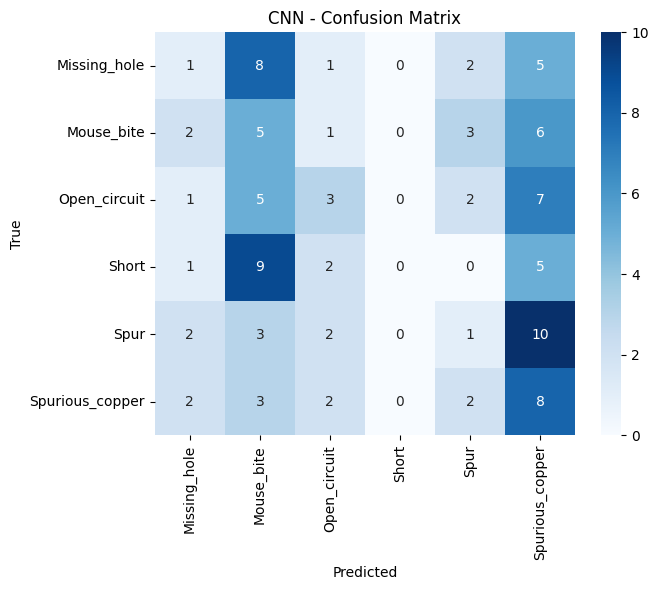

CNN OVR ROC-AUC: 0.4534

ResNet Test Accuracy: 0.1635
                 precision    recall  f1-score   support

   Missing_hole     0.0000    0.0000    0.0000        17
     Mouse_bite     0.1635    1.0000    0.2810        17
   Open_circuit     0.0000    0.0000    0.0000        18
          Short     0.0000    0.0000    0.0000        17
           Spur     0.0000    0.0000    0.0000        18
Spurious_copper     0.0000    0.0000    0.0000        17

       accuracy                         0.1635       104
      macro avg     0.0272    0.1667    0.0468       104
   weighted avg     0.0267    0.1635    0.0459       104



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


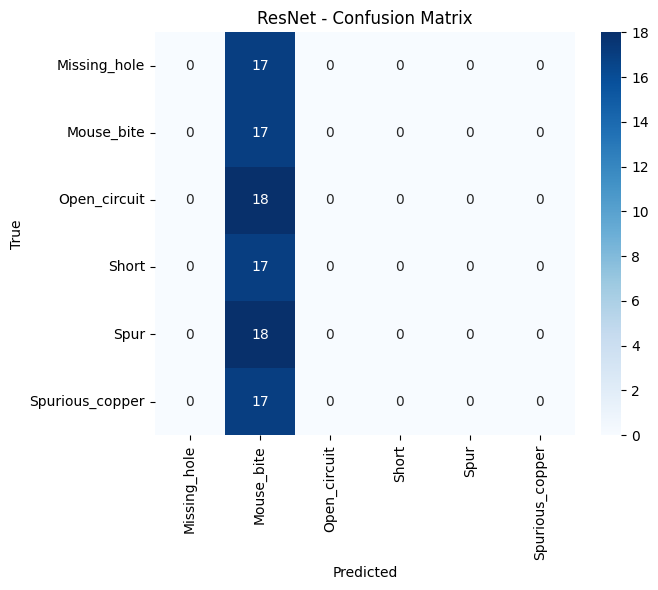

ResNet OVR ROC-AUC: 0.4246
Better model on test set: CNN


In [8]:
from sklearn.preprocessing import label_binarize

def evaluate(model, name):
    criterion = nn.CrossEntropyLoss()
    out = run_epoch(model, test_loader, criterion, None)
    y_true = out['targets']
    y_prob = out['probs']
    y_pred = y_prob.argmax(axis=1)

    print(f'\n{name} Test Accuracy: {(y_pred == y_true).mean():.4f}')
    print(classification_report(y_true, y_pred, target_names=list(class_to_idx.keys()), digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(class_to_idx.keys()), yticklabels=list(class_to_idx.keys()))
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    y_true_bin = label_binarize(y_true, classes=list(range(len(class_to_idx))))
    try:
        auc = roc_auc_score(y_true_bin, y_prob, multi_class='ovr')
        print(f'{name} OVR ROC-AUC: {auc:.4f}')
    except Exception as e:
        print('AUC skipped:', e)

    return y_true, y_pred

cnn_true, cnn_pred = evaluate(cnn, 'CNN')
res_true, res_pred = evaluate(resnet, 'ResNet')

better_model = resnet if (res_pred == res_true).mean() >= (cnn_pred == cnn_true).mean() else cnn
better_name = 'ResNet' if better_model is resnet else 'CNN'
print('Better model on test set:', better_name)

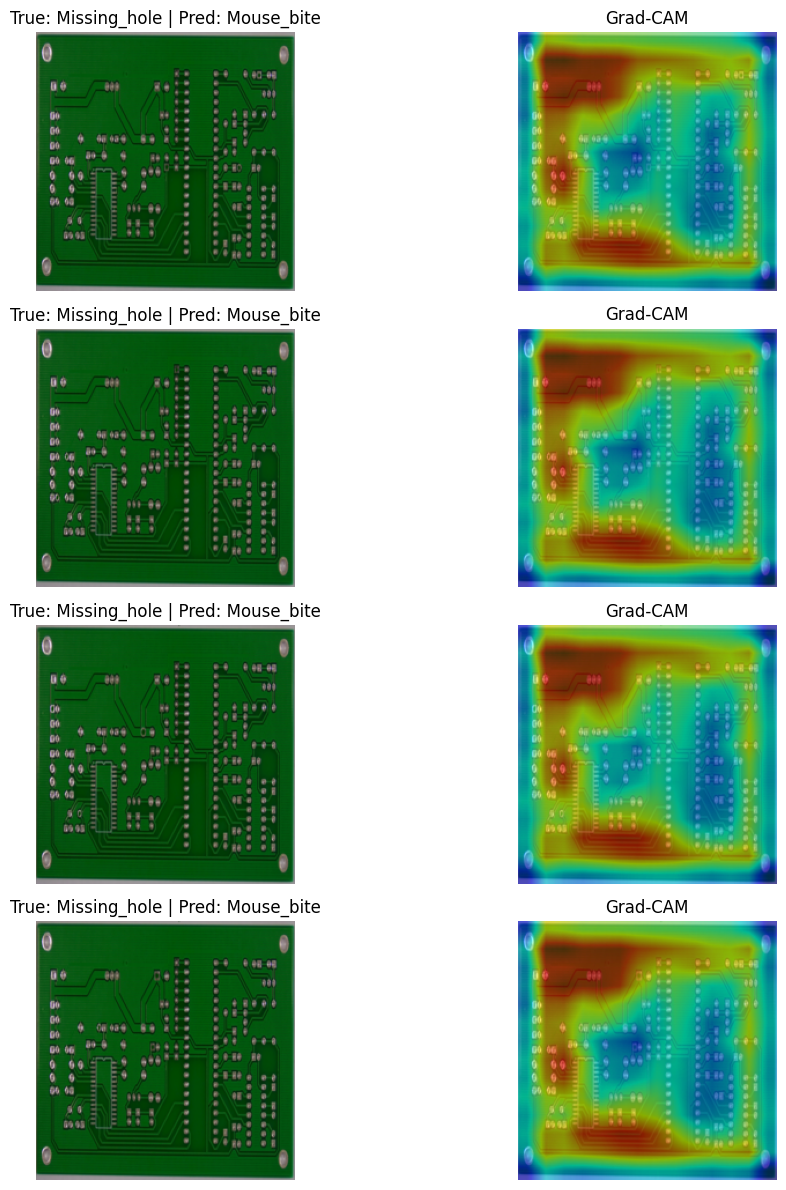

Notebook complete: dataset download, split, train, evaluate, and Grad-CAM done.


In [9]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

if better_model is resnet:
    target_layers = [better_model.layer4.conv2]
else:
    target_layers = [better_model.features[16]]

cam = GradCAM(model=better_model, target_layers=target_layers)
inv_norm = transforms.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225], std=[1/0.229, 1/0.224, 1/0.225])

imgs, labels = next(iter(test_loader))
imgs = imgs.to(device)
out = better_model(imgs)
preds = out.argmax(dim=1)

n_show = min(4, imgs.size(0))
plt.figure(figsize=(12, 3 * n_show))
for i in range(n_show):
    input_tensor = imgs[i].unsqueeze(0)
    target = [ClassifierOutputTarget(int(preds[i].item()))]
    grayscale_cam = cam(input_tensor=input_tensor, targets=target)[0]

    rgb = inv_norm(imgs[i].cpu()).permute(1, 2, 0).numpy()
    rgb = np.clip(rgb, 0, 1)
    vis = show_cam_on_image(rgb, grayscale_cam, use_rgb=True)

    plt.subplot(n_show, 2, 2 * i + 1)
    plt.imshow(rgb)
    plt.axis('off')
    plt.title(f"True: {idx_to_class[int(labels[i])]} | Pred: {idx_to_class[int(preds[i].cpu())]}")

    plt.subplot(n_show, 2, 2 * i + 2)
    plt.imshow(vis)
    plt.axis('off')
    plt.title('Grad-CAM')

plt.tight_layout()
plt.show()

print('Notebook complete: dataset download, split, train, evaluate, and Grad-CAM done.')